# **TITANIC SURVIVAL PREDICTION** 

In [1]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# LOAD DATA

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Shape : {df.shape}")
print(f"\nSample data:")
df.head()

Shape : (891, 12)

Sample data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **EDA** 

In [9]:
# Overview

print("=" * 40)
print("DATASET OVERVIEW")
print("=" * 40)
print(f"Shape    : {df.shape}")
print(f"Columns  : {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

DATASET OVERVIEW
Shape    : (891, 12)
Columns  : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# Target Distribution

print("=" * 40)
print("TARGET DISTRIBUTION (Survived)")
print("=" * 40)
survival_rate = df["Survived"].value_counts(normalize=True) * 100
print(f"Not Survived (0) : {survival_rate[0]:.1f}%")
print(f"Survived (1) : {survival_rate[1]:.1f}%")

TARGET DISTRIBUTION (Survived)
Not Survived (0) : 61.6%
Survived (1) : 38.4%


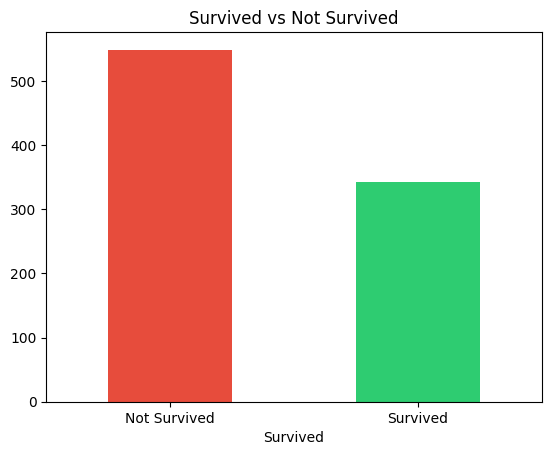

In [13]:
df["Survived"].value_counts().plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.title("Survived vs Not Survived")
plt.xticks([0, 1], ["Not Survived", "Survived"], rotation=0)
plt.show()

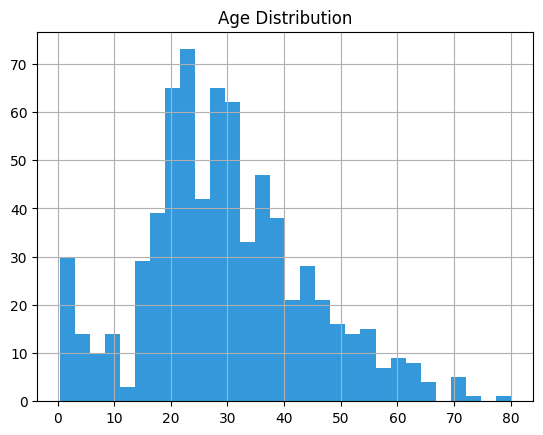

In [15]:
# Age Distribution

df["Age"].hist(bins=30, color="#3498db")
plt.title("Age Distribution")
plt.show()

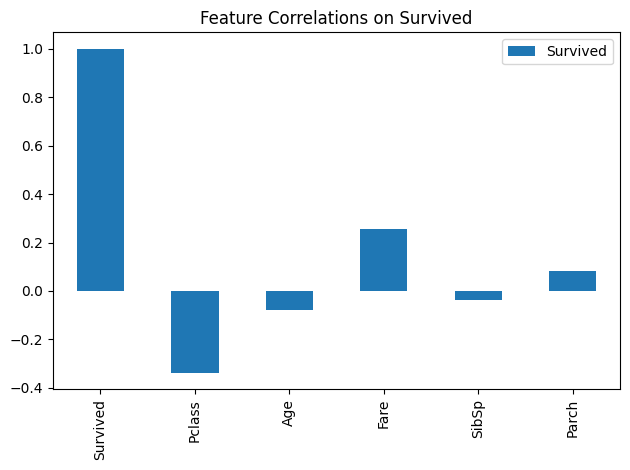

In [24]:
# Correlations

df[["Survived","Pclass","Age","Fare","SibSp","Parch"]].corr()[["Survived"]].plot(kind="bar")
plt.title("Feature Correlations on Survived")
plt.tight_layout()
plt.show()

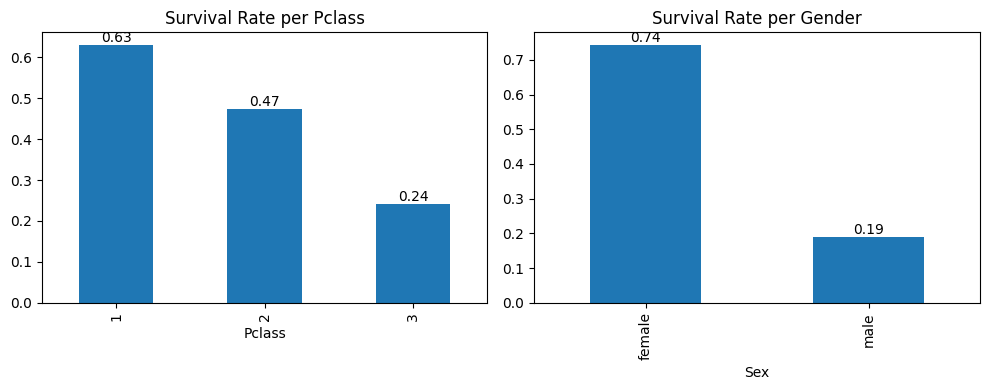

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.groupby("Pclass")["Survived"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Survival Rate per Pclass")
for p in axes[0].patches:                         
    axes[0].annotate(f"{p.get_height():.2f}",      
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom")

df.groupby("Sex")["Survived"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Survival Rate per Gender")
for p in axes[1].patches:                          
    axes[1].annotate(f"{p.get_height():.2f}",      
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom")

plt.tight_layout()
plt.show()

## **Preprocessing**

In [25]:
# Drop Unnecessary Columns

df = df.drop(columns=["Name", "Ticket", "PassengerId", "Cabin"])
print(f"Shape after drop : {df.shape}")

Shape after drop : (891, 8)


In [26]:
# Handle Missing Values

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [28]:
# Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# female=0, male=1
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])

# C=0, Q=1, S=1
df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])
print("\nEncoded data samples:")
df.head()


Encoded data samples:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [29]:
# Feature & Target Split
from sklearn.model_selection import train_test_split

x = df.drop(columns=["Survived"])
y = df["Survived"]

print(f"Features : {list(x.columns)}")
print(f"X Shape : {x.shape}")
print(f"y Shape : {y.shape}")

Features : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X Shape : (891, 7)
y Shape : (891,)


## **Modeling** 

In [30]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")

X_train : (712, 7)
X_test : (179, 7)


In [32]:
# Numerical Features Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import (accuracy_score, classification_report,
#                               confusion_matrix)